In [1]:
#upload file from local system
from google.colab import files
uploded=files.upload()
file_name=list(uploded.keys())[0]

Saving svm_farming_datasets.xlsx to svm_farming_datasets.xlsx


In [2]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

#load dataset
df=pd.read_excel(file_name)
print("Dataset loaded successfully!\n")
print(df.head())

Dataset loaded successfully!

  Sample ID  Soil Nitrogen (mg/kg)  Avg Rainfall (mm)  Class Label    Class
0      W001                  70.83             602.05            1  Healthy
1      W002                  75.15             556.55            1  Healthy
2      W003                  92.58             698.62            1  Healthy
3      W004                  84.47             608.76            1  Healthy
4      W005                  66.91             723.59            1  Healthy



==== Results for C=0.01 ====

accuracy: 1.0
confusion matrix:
 [[12  0]
 [ 0  9]]
classification report:
               precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00        12
    Stressed       1.00      1.00      1.00         9

    accuracy                           1.00        21
   macro avg       1.00      1.00      1.00        21
weighted avg       1.00      1.00      1.00        21


==== Results for C=1 ====

accuracy: 1.0
confusion matrix:
 [[12  0]
 [ 0  9]]
classification report:
               precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00        12
    Stressed       1.00      1.00      1.00         9

    accuracy                           1.00        21
   macro avg       1.00      1.00      1.00        21
weighted avg       1.00      1.00      1.00        21


==== Results for C=100 ====

accuracy: 1.0
confusion matrix:
 [[12  0]
 [ 0  9]]
classification report:
               precision    re

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


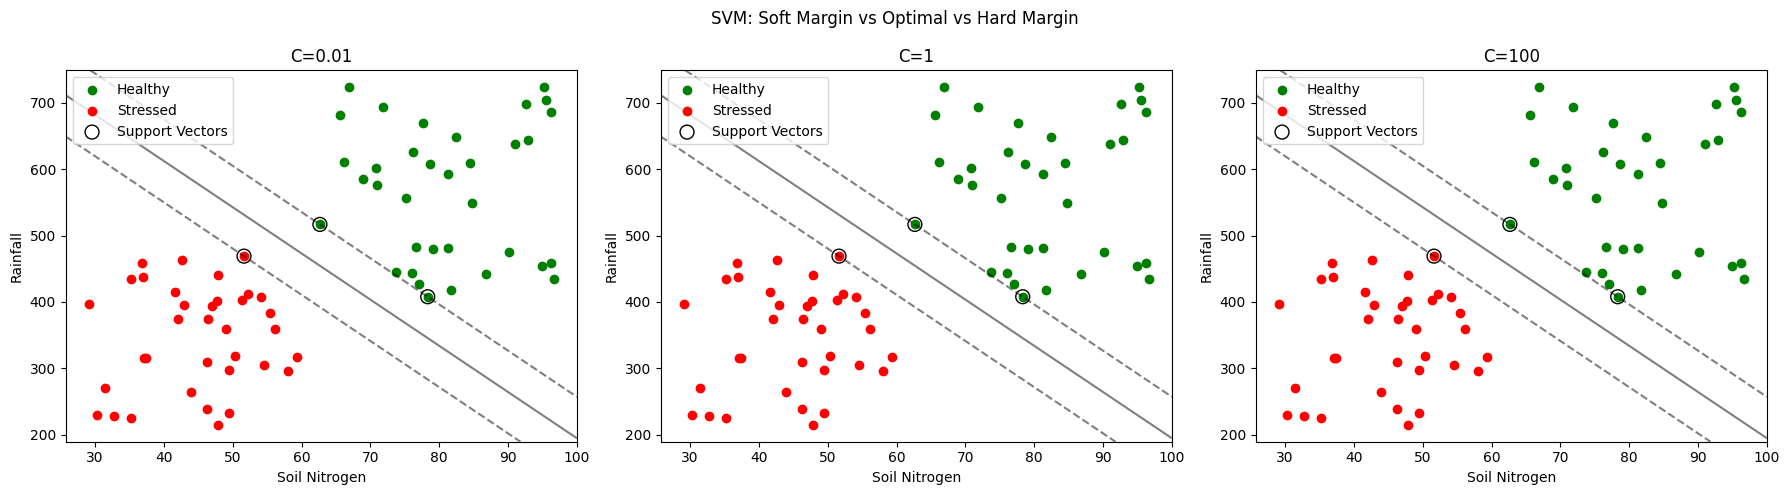

In [4]:
#clean column names(importsnt)
df.columns=df.columns.str.strip()
df.rename(columns={
    "Soil Nitrogen (mg/kg)":"soil_nitrogen",
    "Avg Rainfall (mm)":"rainfall"
},inplace=True)
if "Sample ID" in df.columns:
    df.drop(columns=["Sample ID"],inplace=True)
if 'Class Label' in df.columns:
  df.drop(columns=['Class Label'],inplace=True)
  #Features and Labels
x=df[["soil_nitrogen","rainfall"]]
y=df["Class"]#Now,'Class' is guaranteed to be the nnumerical 1D series
#train-Test Split
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.3,random_state=42
)
#function:train+evaluate+plot
def train_and_plot(C,subplot_index):
  model=svm.SVC(kernel='linear',C=C)
  model.fit(x_train,y_train)
  #predictions
  y_pred=model.predict(x_test)
  #evaluation
  print(f"\n==== Results for C={C} ====\n")
  print("accuracy:",accuracy_score(y_test,y_pred))
  print("confusion matrix:\n",confusion_matrix(y_test,y_pred))
  print("classification report:\n",classification_report(y_test,y_pred))
  #plotting
  plt.subplot(1,3,subplot_index)
  for label, color in zip(['Healthy', 'Stressed'], ['green', 'red']):
    subset=df[df["Class"]==label]
    plt.scatter(subset["soil_nitrogen"],
    subset["rainfall"],
    c=color,
    label=label)

  #decision boundary
  ax=plt.gca()
  xlim=ax.get_xlim()
  ylim=ax.get_ylim()
  xx=np.linspace(xlim[0],xlim[1],30)
  yy=np.linspace(ylim[0],ylim[1],30)
  YY,XX=np.meshgrid(yy,xx)
  xy=np.vstack([XX.ravel(),YY.ravel()]).T
  Z=model.decision_function(xy).reshape(XX.shape)
  #boundary
  ax.contour(XX,YY,Z,colors='k',levels=[-1,0,1],alpha=0.5,linestyles=['--','-','--'])
  #support vectors
  ax.scatter(model.support_vectors_[:,0],
             model.support_vectors_[:,1],
             s=100,facecolors='none',
             edgecolors='black',
             label='Support Vectors')
  plt.xlabel("Soil Nitrogen")
  plt.ylabel("Rainfall")
  plt.title(f"C={C}")
  plt.legend()

#compare different Cvalues
plt.figure(figsize=(18,5))
C_values=[0.01,1,100]
for i,C in enumerate(C_values):
    train_and_plot(C,i+1)
plt.suptitle("SVM: Soft Margin vs Optimal vs Hard Margin")
plt.tight_layout()
plt.show()